In [1]:
import yaml
import pandas as pd
import numpy as np
from datetime import time
import statsmodels.api as sm
import datetime as dt

from statsmodels.base.model import Model
from tqdm import tqdm
from typing import Literal

# Project Overview

This project analyzes the impact of  news events on intraday market volatility.  
Using high-frequency return data, we estimate how different event types (Ad Hoc, Macro Releases, Auctions, Central Bank) affect volatility levels.  
We quantify both the per-event impact (via regression coefficients) and overall importance (via $\omega_k$ and $\omega_i$ shares), supported by bootstrap-based inference to assess robustness and uncertainty.


---
---
## 1.1 Data Preparation for Event Study on Stock Returns

This section describes the Python code used to prepare high-frequency SPY stock price data and scheduled economic event data. The goal is to examine how events impact intraday volatility in financial markets, particularly the SPY ETF.

---

**1. load_config(path)**  
Loads a configuration file (in YAML format). This file stores important metadata like the analysis year, paths to data files, and start/end dates. This helps make the code reusable for different years or setups.

**2. load_df(type, config)**  
This function loads the data for a specific `type`, either `"SPY"` (stock data) or `"news"` (event data), depending on the configuration. It looks up the correct path from the configuration dictionary and loads the corresponding CSV file into a DataFrame.

**3. to_ger_timestamp(string)**  
This helper function converts a date string to a timezone-aware pandas Timestamp in the `"Europe/Berlin"` timezone. This is necessary because events are often reported in Central European Time (CET/CEST), so aligning the timezones correctly is crucial for accurate event mapping.

**4. prepare_spy_data(data, filter_dates)**  
This is the main preprocessing function for the SPY stock price data.

- **Step 1: Timezone Handling**  
  The datetime column is first converted to `"America/New_York"` (Eastern Time) and then to `"Europe/Berlin"` to match the event data. The frequency is set to 15-minute intervals.

- **Step 2: Time Filtering**  
  Only U.S. trading hours are retained (15:30–22:00 Berlin time), and weekends are removed.

- **Step 3: Cleaning and Volatility Measure**  
  The column `'Unnamed: 0'` is dropped, and missing values are interpolated using time-based interpolation. The volatility proxy `y^2` is computed as the squared log return:

  $$
  y_t^2 = \left( \log(\text{close}_t) - \log(\text{close}_{t-1}) \right)^2
  $$

- **Step 4: Dummy Variables**  
  Dummy variables are created for the day of the week (Monday–Friday) and hour of the day (for intraday fixed effects). These dummies are often useful in regression models to control for cyclical patterns.

- **Step 5: Final Output**  
  The function drops unused columns and returns a cleaned and filtered DataFrame with squared returns and dummy variables, ready for analysis.

---

**Summary**  
This code prepares the SPY price data for event-based econometric analysis by ensuring proper time alignment, frequency consistency, volatility measurement, and fixed-effects control. It enables the integration of high-frequency stock data with timestamped news events for modeling purposes.


In [2]:


#df = pd.read_csv('SPY_15min_2020-01_to_2022-01.csv')


def load_config(path: str):
    """
    Loads the configuration from a YAML file.

    :param path: Path to the YAML configuration file.
    :return: A dictionary containing the configuration.
    """
    with open(path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def load_df(type: Literal["news", "SPY"], config: dict):
    """
    Loads the DataFrame for the specified year from the configuration.

    :param year: The year for which to load the DataFrame.
    :param config: The configuration dictionary containing file paths.
    :return: A pandas DataFrame containing the data for the specified year.
    """
    year = config["year"]
    if type == "news":
        df = pd.read_csv(config["news_path"])
    else:
        try: df = pd.read_csv(config[year])
        except KeyError:
            raise ValueError(f"No file path configured for {year}.")
    return df

def to_ger_timestamp(string: str):
    """
    Converts a string in the format 'YYYY-MM-DD HH:MM:SS' to a timezone-aware timestamp in Europe/Berlin.

    :param string: A string representing a date and time in the format 'YYYY-MM-DD (optional: HH:MM:SS').
    :return: A pandas Timestamp object localized to Europe/Berlin timezone.
    """
    dt_obj = pd.to_datetime(string)
    return dt_obj.tz_localize("Europe/Berlin")

def prepare_spy_data(data: pd.DataFrame, filter_dates: dict):
    """
    Prepares the SPY data by converting the datetime column to a timezone-aware index,
    setting the frequency to 15 minutes, and filtering for the specified time range.

    Please note that in spite of the labeling, "eventstart_CET" is actually Europe7/Berlin as it changes between CET (UTC+1) and CEST (UTC+2).

    :param data: A pandas DataFrame containing the SPY data with a datetime column.
    :param filter_dates: A dictionary with 'start_date' and 'end_date' keys for filtering the data.
    :return: A pandas DataFrame with the prepared SPY data.
    """
    # 1. Timezone specific preparation
    data['datetime'] = pd.to_datetime(data['Unnamed: 0'])
    data['datetime'] = data['datetime'].dt.tz_localize('America/New_York')  # Localize to ET timezone
    data.set_index('datetime', inplace=True)
    data.index = pd.DatetimeIndex(data.index)  # Ensure time-aware index
    data = data.asfreq('15min')  # Ensure the index is at 15-minute frequency
    data.index = data.index.tz_convert("Europe/Berlin") # Ensures correct timezone
    data = data.between_time("15:30", "22:00")
    data = data[data.index.weekday < 5]  # Keep only Monday (0) through Friday (4)

    # 2. Other preparations
    data.drop(columns=['Unnamed: 0'], inplace=True)  # Drop the original datetime column to avoid interpolation issues
    data.interpolate(method='time', inplace=True)
    data["y^2"] = (data["close"].apply(lambda x: np.log(x)).diff()) ** 2
    data = data.loc[filter_dates["start_date"]:filter_dates["end_date"]]

     # 3. Dummies
    data["day_of_week"] = data.index.dayofweek
    data["hour_of_day"] = data.index.hour
    day_dummies = pd.get_dummies(data["day_of_week"], prefix="FE_day", drop_first=True)
    hour_dummies = pd.get_dummies(data["hour_of_day"], prefix="FE_hour", drop_first=True)
    data = pd.concat([data, day_dummies, hour_dummies], axis=1)

    return data.drop(columns=["open", "high", "low", "volume", "close", "day_of_week", "hour_of_day"])

config = load_config("config.yaml")
filter_dates = {"start_date": to_ger_timestamp(config["start_date"]), "end_date": to_ger_timestamp(config["end_date"])}
filter_dates.values()
df = prepare_spy_data(load_df("SPY", config), filter_dates)
df

,y^2,FE_day_1,FE_day_2,FE_day_3,FE_day_4,FE_hour_16,FE_hour_17,FE_hour_18,FE_hour_19,FE_hour_20,FE_hour_21,FE_hour_22
datetime,,,,,,,,,,,,
2020-01-03 15:30:00+01:00,4.245277e-05,False,False,False,True,False,False,False,False,False,False,False
2020-01-03 15:45:00+01:00,1.896942e-07,False,False,False,True,False,False,False,False,False,False,False
2020-01-03 16:00:00+01:00,3.487367e-08,False,False,False,True,True,False,False,False,False,False,False
2020-01-03 16:15:00+01:00,2.421707e-08,False,False,False,True,True,False,False,False,False,False,False
2020-01-03 16:30:00+01:00,1.399066e-06,False,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28 21:00:00+02:00,2.004112e-06,False,False,False,True,False,False,False,False,False,True,False
2020-08-28 21:15:00+02:00,7.707881e-07,False,False,False,True,False,False,False,False,False,True,False
2020-08-28 21:30:00+02:00,5.239030e-08,False,False,False,True,False,False,False,False,False,True,False


---
## 1.2 Safe Timestamp Shifting Within Market Hours

This section describes the logic and purpose of the `safe_add` function, which is essential for event studies using high-frequency financial data. The goal is to safely shift timestamps forward or backward while ensuring they remain within official U.S. market hours.

---

**Function:** `safe_add(column, value)`

- **Purpose:**  
  This function safely adds or subtracts a number of minutes to a `DatetimeIndex`, ensuring that the resulting timestamp remains within valid market hours. It replicates the logic presented in the internet appendix of the corresponding academic study.

- **Inputs:**  
  - `column`: A pandas Series with timezone-aware datetime values.  
  - `value`: Integer number of minutes to shift the time forward (positive) or backward (negative).

---

**Step-by-step Explanation:**

1. **Validation:**  
   The function first checks whether the input column is a datetime Series and whether it contains timezone-aware timestamps.

2. **Timezone Alignment:**  
   The index is converted to Eastern Time (`America/New_York`) to align with the typical U.S. stock market hours.

3. **Classifying Time Windows:**  
   Each timestamp is classified into one of three categories based on its time component:
   - Before market open: $\text{time} < 09{:}30$
   - During market hours: $09{:}30 \leq \text{time} \leq 16{:}00$
   - After market close: $\text{time} > 16{:}00$

4. **Shifting Timestamps:**
   - If `value >= 0`:
     - Before open $\rightarrow$ set to 09:30 of the same day and shift
     - After close $\rightarrow$ set to 09:30 of the next day and shift
     - During open hours $\rightarrow$ shift directly
   - If `value < 0`:
     - Before open $\rightarrow$ move to 16:00 of the previous day
     - After close $\rightarrow$ move to 16:00 of the same day
     - During open hours $\rightarrow$ shift directly

5. **Return:**
   The function returns the shifted datetime values, all of which remain within valid market trading hours.

---

**Why This Matters:**

In high-frequency financial studies, it is often necessary to examine price changes shortly before or after a news event. However, naive shifting of timestamps (e.g., subtracting 15 minutes) may result in times outside market hours (e.g., 03:00 AM). This creates issues in data alignment and econometric modeling.

The `safe_add` function solves this by constraining all shifted timestamps to legal trading times. It ensures robust and realistic modeling of how markets react to news, without introducing temporal distortions.



In [3]:
def safe_add(column: pd.Series, value: int): # Expects a datetimeIndex
    """
    Safely adds or subtracts a value in minutes to/from a datetime index, ensuring that the result remains within market open hours.
    This function is based on the internet appendix of the provided paper, thus, more information can be found there.

    :param column: A pandas Series with a DatetimeIndex, expected to be timezone-aware.
    :param value: An integer representing the number of minutes to add (positive) or subtract (negative).
    :return: A pandas Series with the same index, adjusted by the specified value in minutes.
    """
    # Confirm that the column has dates
    if not pd.api.types.is_datetime64_any_dtype(column):
        raise TypeError("Excpected a DateTime Series.")
    # Check if the index is timezone-aware
    if column.dt.tz is None:
        raise ValueError("DatetimeIndex must be timezone-aware.")
    # Cast to ET timezone for timezone aware consistency
    column = column.dt.tz_convert("America/New_York")
    # Check whether value is outside of market open hours
    hypothetical_values = column + pd.Timedelta(minutes=value)

    mask_before_open = (hypothetical_values.dt.time < dt.time(9,30))
    mask_during_open = (dt.time(9,30) <= hypothetical_values.dt.time) & (hypothetical_values.dt.time <= dt.time(16,0))
    mask_after_open = (hypothetical_values.dt.time > dt.time(16,0))

    date_of_action = column.dt.normalize() # Extract date and set hours to 0:00
    output = column.copy()
    output[mask_during_open] = output[mask_during_open] + pd.Timedelta(minutes=value)
    if value >= 0: # Safe add
        output[mask_before_open] = date_of_action[mask_before_open] + pd.Timedelta(hours=9, minutes=30) + pd.Timedelta(minutes=value)
        output[mask_after_open] = date_of_action[mask_after_open] + pd.Timedelta(days=1) + pd.Timedelta(hours=9, minutes=30) + pd.Timedelta(minutes=value)
    else: # Safe subtract
        # Window starts when trading closes
        output[mask_before_open] = date_of_action[mask_before_open] - pd.Timedelta(days=1) + pd.Timedelta(hours=16)
        output[mask_after_open] = date_of_action[mask_after_open] + pd.Timedelta(hours=16)

    return output # Caution: returns series with ET timezone

## 1.3 Event Data Preparation for Intraday Impact Analysis

This section describes the Python code used to process scheduled and unscheduled financial news events. The goal is to define precise time windows around each event during which market impact (e.g., volatility or return changes) will be analyzed.

---

**prepare_news_df(data)**  
This function prepares a DataFrame of economic news events by parsing timestamps, filtering by date range, and defining event-specific time windows. Each news entry is assigned a window within which market reactions are expected to occur.

- **Timezone Handling**  
  The function converts `eventstart_CET` and `eventend_CET` columns to timezone-aware timestamps in `"Europe/Berlin"`. This is essential because economic events are typically scheduled in Central European Time (CET/CEST).

- **Date Filtering**  
  The dataset is restricted to a specific analysis period defined by `filter_dates`. This ensures only relevant events are considered, aligning them with available stock market data.

- **Mask Definitions**  
  Two masks are defined:
  - `event_end_mask`: Indicates whether an event has a known end time.
  - `ad_hoc_mask`: Identifies "Ad Hoc" events that are treated differently due to their unplanned nature.

- **Window Assignment: Without End Time**  
  For events without an end time:
  - The event window starts 15 minutes before the event.
  - It ends 30 minutes after the event.
  
  These windows are generated using the `safe_add` function, which ensures time additions respect trading hours (e.g., no windows during night or weekends).

- **Window Assignment: Ad Hoc Events**  
  For "Ad Hoc" events, the post-event window is extended to 60 minutes, assuming that markets may need more time to absorb the surprise.

- **Window Assignment: With End Time**  
  If an event has both a start and end time:
  - The window begins 20 minutes before the start.
  - It ends 20 minutes after the end.

  This captures both anticipatory and delayed market reactions.

---

**Functionality Summary:**  
The resulting DataFrame contains two new columns:
- `window_start`: The beginning of the relevant market reaction window.
- `window_end`: The end of that window.

These windows will later be used to map each event onto stock return data and study how much of the market variance can be explained by scheduled (or unscheduled) announcements.



In [4]:
def prepare_news_df(data: pd.DataFrame):
    """
    Prepares the news DataFrame by converting the event start and end times to timezone-aware timestamps, filters the data based on the specified date range, and creates time windows for each event.

    :param data: A pandas DataFrame containing news events with 'eventstart_CET' and 'eventend_CET' columns.
    :return: A pandas DataFrame with the prepared news data, including 'window_start' and 'window_end' columns.
    """
    # Ensure correct timezone
    data["eventstart_CET"] = pd.to_datetime(data["eventstart_CET"], format="%d.%m.%Y %H:%M:%S").dt.tz_localize("Europe/Berlin", ambiguous=False)


    data["eventend_CET"] = pd.to_datetime(data["eventend_CET"], format="%d.%m.%Y %H:%M:%S").dt.tz_localize("Europe/Berlin")
    # Filter on timestamps of stock data
    data = data[(data["eventstart_CET"] >= filter_dates["start_date"]) & (data["eventstart_CET"] <= filter_dates["end_date"])]

    #data["eventstart_CET"] = data["eventstart_CET"].dt.floor("15min")  # Optional: Round down to the nearest 15 minutes (not mentioned in paper)

    # Correct time window creation according to paper:
    event_end_mask = data["eventend_CET"].notna()
    ad_hoc_mask = data["type"] == "Ad Hoc"

    # Only assign to rows where event_end_mask is False
    data.loc[~event_end_mask, "window_start"] = (
        safe_add(data.loc[~event_end_mask, "eventstart_CET"], -15)
        .dt.tz_convert("Europe/Berlin")
    )

    data.loc[~event_end_mask, "window_end"] = (
        safe_add(data.loc[~event_end_mask, "eventstart_CET"], 30)
        .dt.tz_convert("Europe/Berlin")
    )

    data.loc[ad_hoc_mask, "window_end"] = (
        safe_add(data.loc[ad_hoc_mask, "eventstart_CET"], 60)
        .dt.tz_convert("Europe/Berlin")
    )

    # Only assign to rows where event_end_mask is True
    data.loc[event_end_mask, "window_start"] = (
        safe_add(data.loc[event_end_mask, "eventstart_CET"], -20)
        .dt.tz_convert("Europe/Berlin")
    )

    data.loc[event_end_mask, "window_end"] = (
        safe_add(data.loc[event_end_mask, "eventend_CET"], 20)
        .dt.tz_convert("Europe/Berlin")
    )

    return data

df_news = prepare_news_df(load_df("news", config))

df_news

,eventstart,eventend,name,type,subtype,subsubtype,description,source,scheduled,eventstart_CET,eventend_CET,window_start,window_end
49275,02.01.2020 19:00:00,NaT,UK BRC Shop Price Index,Macro Release,UK,BRC Shop Price Index,NaN,Bloomberg,1,2020-01-03 01:00:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49276,03.01.2020 02:45:00,NaT,FR CPI and Wages,Macro Release,FR,CPI and Wages,NaN,Bloomberg,1,2020-01-03 08:45:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49277,03.01.2020 03:00:00,NaT,ES Unemployment Net,Macro Release,ES,Unemployment Net,NaN,Bloomberg,1,2020-01-03 09:00:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49278,03.01.2020 04:00:00,NaT,DE CPI Hesse,Macro Release,DE,CPI Hesse,NaN,Bloomberg,1,2020-01-03 10:00:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
49279,03.01.2020 04:30:00,NaT,UK Monetary Aggregates,Macro Release,UK,Monetary Aggregates,NaN,Bloomberg,1,2020-01-03 10:30:00+01:00,NaT,2020-01-02 22:00:00+01:00,2020-01-03 16:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51552,28.08.2020 05:00:00,NaT,IT Auction Result Bond or Note,Auction,IT Result,Bond or Note,NaN,Bloomberg,1,2020-08-28 11:00:00+02:00,NaT,2020-08-27 22:00:00+02:00,2020-08-28 16:00:00+02:00
51553,28.08.2020 09:05:00,28.08.2020 09:43:00,BoE: Speech by Governor,Central Bank,BoE,Speech by Governor,"Bailey at Jackson Hole: ""it looks from today’s...",https://www.bankofengland.co.uk/-/media/boe/fi...,0,2020-08-28 15:05:00+02:00,2020-08-28 15:43:00+02:00,2020-08-27 22:00:00+02:00,2020-08-28 16:03:00+02:00
51554,28.08.2020 09:45:00,NaT,US Chicago Purchasing Manager,Macro Release,US,Chicago Purchasing Manager,NaN,Bloomberg,1,2020-08-28 15:45:00+02:00,NaT,2020-08-28 15:30:00+02:00,2020-08-28 16:15:00+02:00
51555,28.08.2020 10:00:00,NaT,US University of Michigan Surveys,Macro Release,US,University of Michigan Surveys,NaN,Bloomberg,1,2020-08-28 16:00:00+02:00,NaT,2020-08-28 15:45:00+02:00,2020-08-28 16:30:00+02:00


## 2.1 Creating Event Dummies for Econometric Analysis

This section explains the Python function used to generate binary dummy variables that flag the presence of macroeconomic news events during specific time intervals in high-frequency SPY trading data. These dummy variables serve as regressors to quantify the impact of news on market behavior.

---

**create_news_dummies(spy_df, news_df, group_by = "type")**  
This function augments the SPY dataset with dummy variables that indicate whether an event of a given category is active during each 15-minute interval.

- **Event Grouping**  
  The news DataFrame is grouped by a specified column (e.g., `"type"` or `"subsubtype"`), allowing the user to create dummies at various levels of aggregation, such as "Interest Rate Decisions", "GDP Releases", or more granular event types.

- **Boolean Mask Initialization**  
  For each event group, a Boolean mask is initialized. This mask marks all timestamps where the SPY index lies within the `window_start` and `window_end` interval of any event in the group.

- **Iterative Event Mapping**  
  The function iterates through each event within the group and updates the mask accordingly by checking whether the timestamp is inside the defined reaction window.

- **Dummy Column Creation**  
  Once the mask is complete for a group, it is stored as a new column named `D_<event_type>`, where `<event_type>` corresponds to the value of the `group_by` variable.

- **Concatenation with SPY Data**  
  After processing all groups, the generated dummy columns are concatenated with the original SPY DataFrame, yielding a dataset ready for regression analysis.

---

These dummy variables are critical for attributing portions of intraday return variance to specific types of events. By encoding when an event is expected to influence the market, they enable the estimation of event-driven return dynamics through regression-based variance decomposition.


In [5]:
def create_news_dummies(spy_df: pd.DataFrame, news_df: pd.DataFrame, group_by: str = "type"):
    """
    Creates dummy variables for news events based on the specified grouping level.

    :param spy_df: A pandas DataFrame containing SPY data with a datetime index.
    :param news_df: A pandas DataFrame containing news events with 'window_start' and 'window_end' columns.
    :param group_by: The column name to group by (e.g., 'subsubtype', 'type').
    :return: A pandas DataFrame with dummy variables for each unique value in the specified grouping column.
    """

    print(f"creating {len(news_df[group_by].unique())} event dummie variables")
    dummies = {}
    for subtype, df_type in news_df.groupby(group_by):
        mask = pd.Series(False, index=df.index)
        for _, row in df_type.iterrows():
            mask = mask | ((spy_df.index > row["window_start"]) & (spy_df.index <= row["window_end"]))
        dummies[f"D_{subtype}"] = mask

    return pd.concat([spy_df, pd.DataFrame(dummies)], axis=1)

df_complete = create_news_dummies(df, df_news, group_by="type")
df_complete

creating 4 event dummie variables


,y^2,FE_day_1,FE_day_2,FE_day_3,FE_day_4,FE_hour_16,FE_hour_17,FE_hour_18,FE_hour_19,FE_hour_20,FE_hour_21,FE_hour_22,D_Ad Hoc,D_Auction,D_Central Bank,D_Macro Release
datetime,,,,,,,,,,,,,,,,
2020-01-03 15:30:00+01:00,4.245277e-05,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
2020-01-03 15:45:00+01:00,1.896942e-07,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
2020-01-03 16:00:00+01:00,3.487367e-08,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
2020-01-03 16:15:00+01:00,2.421707e-08,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
2020-01-03 16:30:00+01:00,1.399066e-06,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28 21:00:00+02:00,2.004112e-06,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False
2020-08-28 21:15:00+02:00,7.707881e-07,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False
2020-08-28 21:30:00+02:00,5.239030e-08,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False


## 2.2 Volatility Regression Using Event Dummies

This section describes the Python code used to run a regression analysis that examines how economic news events influence short-term market volatility. The regression is performed on the squared log returns of the SPY ETF to estimate the portion of volatility that can be explained by event dummies.

---

**run_regression(df, window_amt)**  
This function runs an Ordinary Least Squares (OLS) regression using a rolling window approach on intraday volatility. It models the squared returns as a function of event indicators and optionally fixed effects (not included in this minimal implementation but supported).

- **Target Variable: Intraday Volatility**  
  The dependent variable is computed as the squared log return over 15-minute intervals:
  $$
  y_t^2 = \left( \log(\text{close}_t) - \log(\text{close}_{t-1}) \right)^2
  $$
  The function rolls a window of size $k = 4$ (1 hour) over this series to measure recent volatility.

- **Explanatory Variables: Event Dummies**  
  Event dummies are binary variables indicating whether a particular type of event occurred in a predefined reaction window. These variables are matched to the timestamp of the SPY data. The model includes one dummy for each type of news event:
  $$
  x_t = [\text{const}, D_1, D_2, \ldots, D_K]
  $$
  where $D_k \in \{0, 1\}$ for each event type $k$.

- **Regression Model**  
  The regression takes the form:
  $$
  y_t^2 = \beta_0 + \sum_{k=1}^K \beta_k D_{k,t} + \epsilon_t
  $$
  where:
  - $y_t^2$ is the squared return at time $t$,
  - $D_{k,t}$ is a dummy for event type $k$,
  - $\beta_k$ quantifies the contribution of event $k$ to volatility,
  - $\epsilon_t$ is the error term.

- **Rolling Offset**  
  Because the squared return is computed using a rolling sum over $k = 4$ observations, the first $k-1$ rows are dropped to avoid using NaN values.

- **Model Output**  
  The result is a fitted `statsmodels` OLS model, which provides estimates $\hat{\beta}_k$, standard errors, $R^2$, and statistical significance for each event dummy.

---

**Purpose**  
This regression allows us to measure how much of the observed intraday volatility in the SPY ETF can be attributed to scheduled (or unscheduled) news announcements. It is a key component of an event-study framework for financial market microstructure research.


In [26]:
# Regression
def run_regression(df: pd.DataFrame, window_amt: int = 4, use_fixed_effects: bool = False, use_lagged_variance: bool = False):
    """
    Runs an OLS regression on the provided DataFrame. Automatically handles the rolling variance calculation based on the specified window amount. Also extracts dummies and fixed effects from the DataFrame. Dummies need to start with "D_" and fixed effects with "FE_".

    :param df: A pandas DataFrame containing the data for regression.
    :param window_amt: The number of 15-minute intervals to use for the rolling variance calculation.
    :return: A fitted OLS model.
    """


    fixed_effects = df.filter(regex="^FE_").astype(float)
    lagged_variance = df['y^2'].rolling(window=window_amt).sum()  # assuming window_amt 15-min intervals according to paper
    lagged_variance.name = "lagged_variance"
    event_dummies = df.filter(regex="^D_").astype(float)

    x = event_dummies
    if use_fixed_effects:
        x = pd.merge(x, fixed_effects, how="left", on="datetime")
    if use_lagged_variance:
        x = pd.merge(x, lagged_variance, how="left", on="datetime")

    x = x.iloc[window_amt-1:] # Account for rolling window
    x = sm.add_constant(x)
    y = df["y^2"].iloc[window_amt-1:].astype(float)

    return sm.OLS(y, x).fit()

model = run_regression(df_complete, window_amt=4)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    y^2   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     27.09
Date:                Sat, 12 Jul 2025   Prob (F-statistic):           2.99e-22
Time:                        16:53:22   Log-Likelihood:                 34894.
No. Observations:                4614   AIC:                        -6.978e+04
Df Residuals:                    4609   BIC:                        -6.975e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            7.639e-06   2.22e-06      3.448      0.001     3.3e-06     1.2e-05
D_Ad Hoc         6.523e-05   1.03e-05      6.319      0.000     4.5e-05    8.55e-05
D_Auction        1.026e-05   4.65e-06      2.205      0.028    1.14e-06    1.94e-05
D_Central Bank   3.571e-06   5.78e-06      0.618      0.537   -7.76e-06    1.49e-05
D_Macro Release  3.151e-05    6.1e-06      5.167      0.000    1.96e-05    4.35e-05
==============================================================================
Omnibus:                     9458.485   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         26451145.551
Skew:                          17.156   Prob(JB):                         0.00
Kurtosis:                     372.337   Cond. No.                         5.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

,y^2,FE_day_1,FE_day_2,FE_day_3,FE_day_4,FE_hour_16,FE_hour_17,FE_hour_18,FE_hour_19,FE_hour_20,FE_hour_21,FE_hour_22,D_Ad Hoc,D_Auction,D_Central Bank,D_Macro Release
datetime,,,,,,,,,,,,,,,,
2020-01-03 15:30:00+01:00,4.245277e-05,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
2020-01-03 15:45:00+01:00,1.896942e-07,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
2020-01-03 16:00:00+01:00,3.487367e-08,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
2020-01-03 16:15:00+01:00,2.421707e-08,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
2020-01-03 16:30:00+01:00,1.399066e-06,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28 21:00:00+02:00,2.004112e-06,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False
2020-08-28 21:15:00+02:00,7.707881e-07,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False
2020-08-28 21:30:00+02:00,5.239030e-08,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False


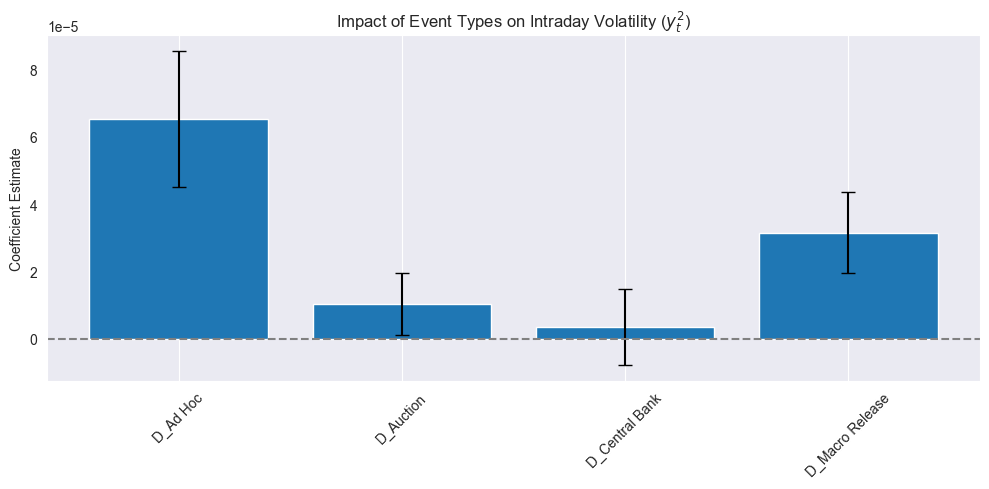

In [7]:
import matplotlib.pyplot as plt

# Extract relevant data
coefficients = model.params.drop("const")
errors = model.bse.drop("const")
labels = coefficients.index

# Plot
plt.figure(figsize=(10, 5))
plt.bar(labels, coefficients, yerr=1.96*errors, capsize=5)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Impact of Event Types on Intraday Volatility ($y_t^2$)")
plt.ylabel("Coefficient Estimate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


## 2.3 Regression Results Interpretation

This regression estimates the effect of different event types on intraday volatility, proxied by squared log returns (\( y_t^2 \)). The baseline volatility (`const`) is relatively low, indicating stable market conditions in the absence of event-driven news.

#### D_Ad Hoc  
- **Coefficient**: \( 6.52 \times 10^{-5} \), **p < 0.001**  
- **Reason for High Effect**: Ad hoc disclosures are firm-specific, unscheduled, and often contain material new information (e.g. earnings surprises, strategic shifts). Because markets are typically unprepared, these events trigger immediate repricing and high volatility.

#### D_Auction  
- **Coefficient**: \( 1.03 \times 10^{-5} \), **p = 0.028**  
- **Moderate Effect**: Auctions (e.g. government bonds, repo facilities) are scheduled and partially anticipated. While they affect short-term liquidity and pricing, their informational novelty is limited, explaining the smaller but still significant effect.

#### D_Central Bank  
- **Coefficient**: \( 3.57 \times 10^{-6} \), **p = 0.537**  
- **Low and Insignificant**: Central bank events often follow structured communication strategies ("forward guidance"). As a result, markets price in expectations in advance, leading to weak or negligible volatility surprises.

#### D_Macro Release  
- **Coefficient**: \( 3.15 \times 10^{-5} \), **p < 0.001**  
- **Strong Impact**: Macroeconomic releases (e.g. inflation, GDP, unemployment) contain system-wide, high-stakes information. Because they directly influence monetary policy expectations and risk pricing, they cause broad market reactions and sharp increases in volatility.

**Why Are the Coefficients Numerically Small?**

Squared log returns from intraday data are typically very small in absolute value (often \( 10^{-6} \) to \( 10^{-5} \)), since price changes over short intervals are small. Therefore, even seemingly small coefficients represent **large relative changes** in volatility — often multiples of the baseline level.

---
---

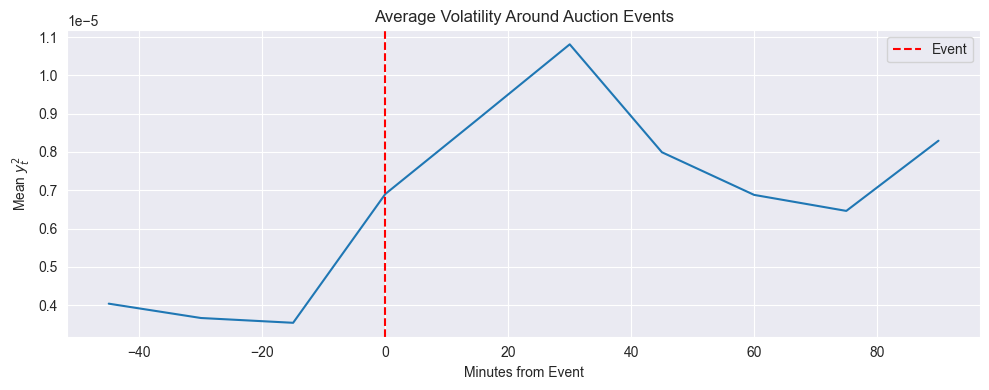

In [8]:
event_type = "D_Auction"
window_before = 60   # in minutes
window_after = 90    # in minutes
interval = 15        # interval in minutes

event_indices = df_complete[df_complete[event_type] == 1].index
volatility_windows = []

for idx in event_indices:
    # Prüfen, ob genug Daten im gewünschten Zeitfenster vorhanden sind
    start_time = idx - pd.Timedelta(minutes=window_before)
    end_time = idx + pd.Timedelta(minutes=window_after)
    window_data = df_complete.loc[start_time:end_time]["y^2"]
    
    if len(window_data) == ((window_before + window_after) // interval + 1):
        volatility_windows.append(window_data.values)

# Nur wenn gültige Fenster gefunden wurden
if volatility_windows:
    mean_volatility = np.mean(volatility_windows, axis=0)
    x_vals = np.arange(-window_before, window_after + interval, interval)

    # Schneide den ersten Punkt weg (links außen, z. B. -60 Minuten)
    mean_volatility = mean_volatility[1:]
    x_vals = x_vals[1:]

    plt.figure(figsize=(10, 4))
    plt.plot(x_vals, mean_volatility)
    plt.axvline(0, color='red', linestyle='--', label='Event')
    plt.title("Average Volatility Around Auction Events")
    plt.xlabel("Minutes from Event")
    plt.ylabel("Mean $y_t^2$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No valid volatility windows found for plotting.")



### Interpretation: Volatility Around Auction Events

The plot shows the average intraday volatility (proxied by $\mathbb{E}[y_t^2]$) in the time window surrounding Auction events.

#### Key Insights

- **Before the event** (−45 to 0 minutes): Volatility is relatively low and stable, indicating no significant anticipation or uncertainty in the lead-up to auctions.
- **At the event** (0 minutes) and shortly after: Volatility increases sharply, peaking around 30 minutes post-event.
- **Post-event decay**: After the peak, volatility gradually declines but remains slightly elevated.

### Interpretation

This pattern suggests that auction outcomes — such as bond allocation or interest rate signals — are **processed by markets shortly after the event**, causing temporary volatility spikes. The absence of pre-event movement implies auctions are largely expected, but **their results still contain price-relevant information** that briefly affects market behavior.


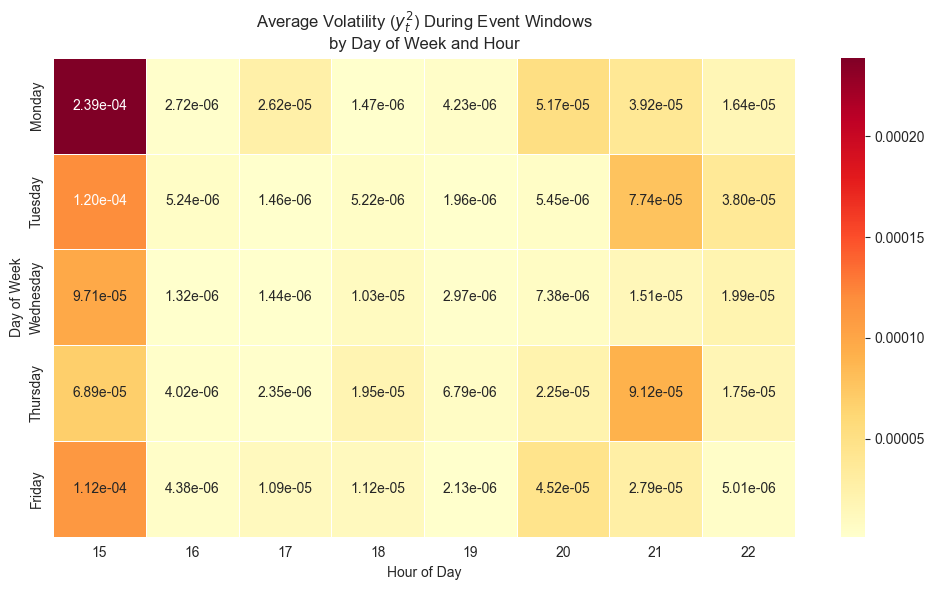

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Event-Zeitstempel filtern: Nur Zeitpunkte, an denen mindestens ein Eventdummy aktiv ist
event_times = df_complete[df_complete.filter(regex="^D_").sum(axis=1) > 0].copy()

# 2. Neue Spalten für Stunde und Wochentag erstellen
event_times["hour"] = event_times.index.hour
event_times["weekday"] = event_times.index.day_name()

# 3. Gruppieren und Mittelwert der Volatilität berechnen
heatmap_data = event_times.groupby(["weekday", "hour"])["y^2"].mean().unstack()

# 4. Wochentage sortieren (damit sie nicht alphabetisch kommen)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
heatmap_data = heatmap_data.reindex(weekday_order)

# 5. Plotten
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".2e", linewidths=0.5)
plt.title("Average Volatility ($y_t^2$) During Event Windows\nby Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


## Heatmap Interpretation: Intraday Volatility by Day and Hour

This heatmap shows the average intraday volatility (measured as squared log returns \( y_t^2 \)) during event windows, broken down by day of the week and hour of day (in 24-hour format). Volatility is particularly elevated at specific times, offering insight into market dynamics and behavioral patterns.

#### Key Observations and Interpretations

#### High Volatility at 15:00 (U.S. Market Open)
- Across all weekdays, the 15:00 slot exhibits consistently elevated volatility, with **Monday at 15:00** showing the **highest single value** in the dataset: \( 2.39 \times 10^{-4} \).
- **Explanation**: 15:00 corresponds to **9:00 AM U.S. Eastern Time**, the moment major U.S. markets (e.g., NYSE, NASDAQ) open. This is a period of high trading volume, price discovery, and immediate reaction to overnight global news.
- Institutional investors often execute batch orders at the open, amplifying short-term volatility.

#### Monday: Structurally Highest Volatility
- Monday stands out as the day with **persistently high volatility**, especially early in the day (15:00–16:00).
- **Explanation**:
  - **Weekend information accumulation**: Markets are closed for ~48 hours, during which significant macro, geopolitical, or firm-specific news may accumulate.
  - **Delayed reaction**: Investors adjust portfolios after the information blackout, leading to strong re-pricing at the weekly open.
  - **Behavioral factors**: Trading sentiment and positioning tend to reset on Mondays, potentially increasing risk appetite or uncertainty.

### Conclusion

Volatility is not evenly distributed across time. It spikes around:
1. **Market openings**, especially **U.S. open at 15:00 CET**
2. **Week starts**, due to **weekend information gaps**

These patterns reflect a combination of institutional behavior, information flows, and market structure — essential knowledge for volatility forecasting, event studies, and intraday trading strategies.


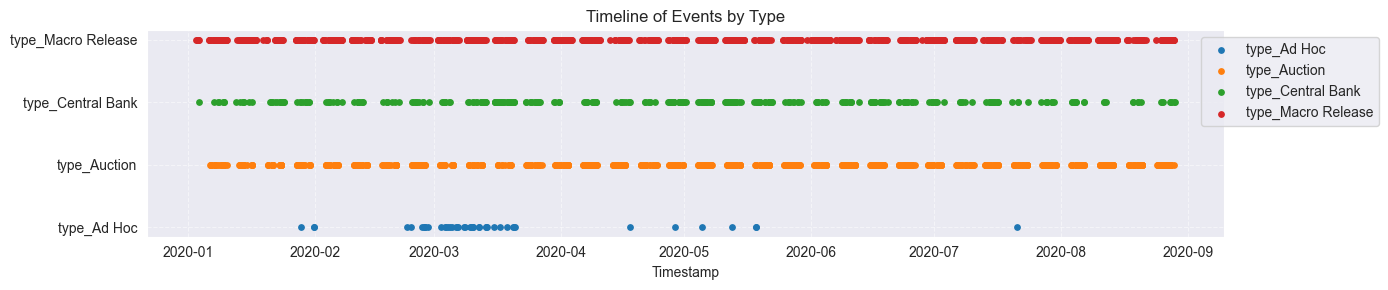

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure your DataFrame is defined as df_news before this step

# Convert timestamps
df_news["eventstart_CET"] = pd.to_datetime(df_news["eventstart_CET"])

# Get unique event types
event_types = df_news["type"].unique()
colors = plt.cm.tab10(range(len(event_types)))

# Plot timeline
plt.figure(figsize=(14, 3))
for i, event_type in enumerate(sorted(event_types)):
    timestamps = df_news[df_news["type"] == event_type]["eventstart_CET"]
    plt.scatter(timestamps, [f"type_{event_type}"] * len(timestamps), 
                label=f"type_{event_type}", s=15, color=colors[i])

plt.xlabel("Timestamp")
plt.yticks(rotation=0)
plt.title("Timeline of Events by Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
plt.tight_layout()
plt.show()


### Event Timeline Interpretation

This timeline visualizes the distribution of four event types over time in 2020. Each dot represents an individual event occurrence.

#### Key Observations

- **Macro Releases** (red) occur at regular, high frequency throughout the entire period, reflecting scheduled economic data publications.
- **Auctions** (orange) and **Central Bank events** (green) are also evenly spaced, indicating predictable, recurring scheduling (e.g. policy meetings or bond issuances).
- **Ad Hoc Events** (blue) are clustered heavily in **March and April 2020**, then become rare.

#### Interpretation of Ad Hoc Cluster

The spike in Ad Hoc events during March–April 2020 coincides with the **first wave of the COVID-19 pandemic**, when firms and institutions issued frequent unscheduled updates (e.g. profit warnings, operational changes, emergency measures). This explains the high density of news and may account for elevated volatility in that period.


---
---
## 3.1 Measuring the Explanatory Power of News Events with $\Omega_k$

This section introduces the concept and implementation of the $\Omega_k$ metric, a key measure in financial event studies for quantifying the explanatory power of news on market volatility.

---

**Function: `compute_omega_k(model, df, k)`**  
This Python function computes the $\Omega_k$ statistic, which quantifies how much of the average market volatility can be attributed to the top $k$ most influential event types based on their statistical significance in a regression model.

---

**Step-by-Step Breakdown:**

- **Event Selection:**  
  All columns in the dataset that represent news event dummies (those prefixed with `"D_"`) are extracted. These dummies indicate the presence of a specific type of event at each 15-minute interval.

- **Statistical Ranking:**  
  For each event dummy, the absolute value of the $t$-statistic from the OLS regression is calculated. The $k$ events with the highest $|t|$ values are selected as the most statistically relevant.

- **Omega Calculation:**  
  The core formula for $\Omega_k$ is:

  $$
  \Omega_k = \frac{\sum_{i=1}^{k} \hat{\beta}_i \cdot \mathbb{E}[D_i]}{\mathbb{E}[y_t^2]}
  $$

  Where:  
  - $\hat{\beta}_i$ is the estimated coefficient for event type $i$  
  - $\mathbb{E}[D_i]$ is the average occurrence probability of event $i$  
  - $\mathbb{E}[y_t^2]$ is the average squared log return (proxy for unconditional volatility)

  This formula weights each event's impact by both its **magnitude** (via $\hat{\beta}_i$) and **frequency** (via $\mathbb{E}[D_i]$).

---

**Economic Interpretation:**

- The $\Omega_k$ statistic tells us the proportion of **average market volatility** that can be **structurally explained** by the $k$ most impactful event types.

- For example, if $\Omega_4 = 0.22$, it means that the top 4 news categories account for 22% of the average squared return variability over the observation period.

---

**Use Case in Financial Research:**

$\Omega_k$ is useful when comparing how different types of economic news affect markets. It can also:
- Reveal which event types systematically matter most,  
- Support regulatory assessments on market transparency,  
- Guide investors in risk forecasting around macroeconomic releases.

This approach goes beyond simple correlation by isolating persistent, repeatable effects of structured information events on intraday market volatility.


In [11]:
# Compute Omega_k
def compute_omega_k(model, df: pd.DataFrame, k: int):
    """
    Computes the Omega_k value based on the fitted OLS model and the DataFrame.

    :param model: A fitted OLS model from statsmodels.
    :param df: A pandas DataFrame containing the data with a column "y^2" representing the squared returns.
    :param k: Number of top k columns based on t-statistics.
    :return: The computed Omega_k value and the top k columns based on t-statistics.
    """
    event_columns = df.filter(regex="^D_").columns  # Select only event dummies
    tstats = model.tvalues[event_columns].abs()  # Absolute t-statistics
    top_k_columns = tstats.nlargest(k).index  # Select top k columns based on t-statistics
    betas = model.params[top_k_columns]

    # Formula from paper
    p_d_eq_1 = df[top_k_columns].mean()
    product = betas * p_d_eq_1
    mu_ysqr = np.mean(df["y^2"].dropna())  # Mean of y^2, excluding the first rows due to rolling window
    omega_k = sum(product) / mu_ysqr

    return omega_k, top_k_columns
k = 4 # Number of top news types to consider
omega, top_k_columns = compute_omega_k(model, df_complete, k)
print(top_k_columns)
print(omega)

Index(['D_Ad Hoc', 'D_Macro Release', 'D_Auction', 'D_Central Bank'], dtype='object')
0.5588923884655664


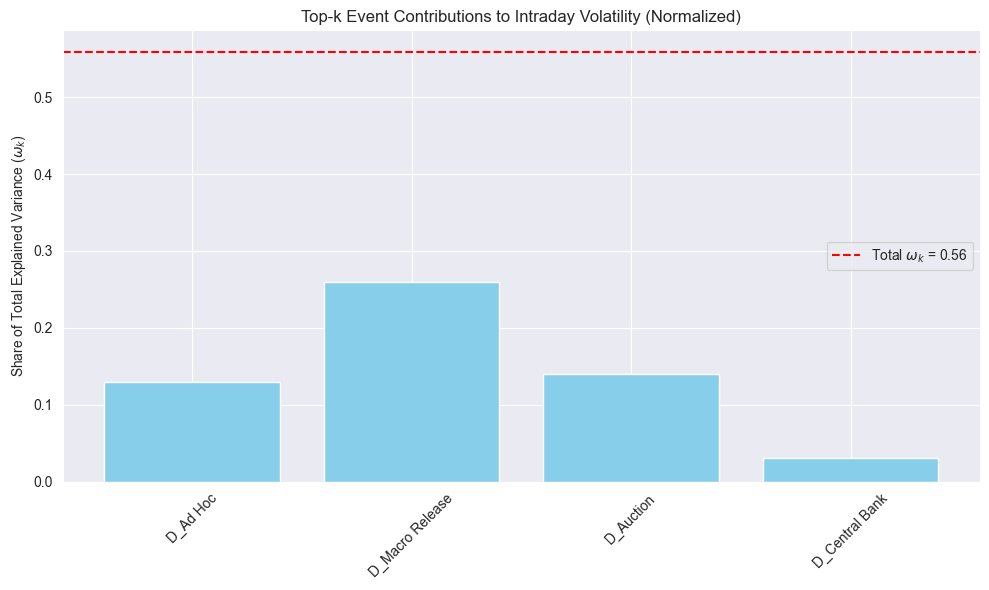

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Daten extrahieren
event_columns = top_k_columns
betas = model.params[event_columns]
p_d_eq_1 = df_complete[event_columns].mean()
contributions = betas * p_d_eq_1
mu_ysqr = np.mean(df_complete["y^2"].dropna())

# Normiert auf den Anteil an Omega_k
normalized_contributions = contributions / mu_ysqr

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(event_columns, normalized_contributions, color='skyblue')
plt.ylabel("Share of Total Explained Variance ($\\omega_k$)")
plt.title("Top-k Event Contributions to Intraday Volatility (Normalized)")
plt.xticks(rotation=45)
plt.axhline(y=sum(normalized_contributions), color='red', linestyle='--', label=f'Total $\\omega_k$ = {omega:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

## 3.2 $\omega_k$ Interpretation: Event Contributions to Intraday Volatility

This bar chart shows the normalized contributions of different event types to total explained intraday volatility, denoted as $\omega_k$. It answers the question: "Which event types explain the most of the total volatility observed in the market?"

#### Key Observations

- The **total explained variance** by the top-k events is **$\omega_k = 0.56$** (dashed red line), meaning that 56% of intraday volatility can be attributed to these event types.
- **Macro Releases** contribute the largest share, followed by **Ad Hoc**, **Auctions**, and lastly **Central Bank** events.

#### Why is $\omega_k^{\text{Macro}} > \omega_k^{\text{Ad Hoc}}$, despite a smaller $\beta$?

Although **Ad Hoc events** have a **higher coefficient** $\hat{\beta}$ — meaning they cause larger volatility spikes per event — they occur **much less frequently**. 

**Macro Releases** occur **regularly and frequently**, which allows their (moderate) per-event impact to accumulate into a **larger total variance contribution**.  
In contrast, **Ad Hoc events**, while impactful, are **rare**, limiting their aggregate explanatory power.

### Conclusion

Macro Releases dominate the explained volatility because their **high frequency** outweighs their lower per-event impact. Ad Hoc events are powerful but infrequent. This highlights the importance of considering both **magnitude** and **frequency** when assessing event relevance in volatility modeling.


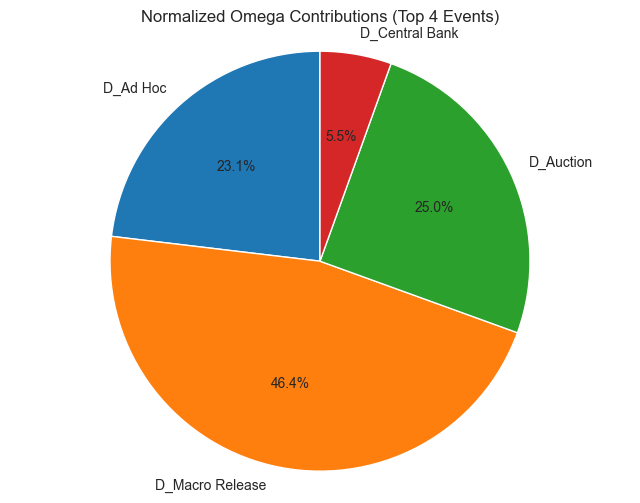

In [13]:
def plot_normalized_omega_pie(model, df, k=4):

    # Select dummy columns
    event_columns = df.filter(regex="^D_").columns
    tstats = model.tvalues[event_columns].abs()
    top_k_columns = tstats.nlargest(k).index
    betas = model.params[top_k_columns]
    p_d_eq_1 = df[top_k_columns].mean()

    # Contribution to Omega_k for each top event type
    contributions = betas * p_d_eq_1
    total_contribution = contributions.sum()
    omega_shares = contributions / total_contribution  # normalized (sum = 1)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.pie(omega_shares, labels=top_k_columns, autopct="%1.1f%%", startangle=90)
    plt.title(f"Normalized Omega Contributions (Top {k} Events)")
    plt.axis("equal")  # Equal aspect ratio ensures pie is a circle
    plt.show()

plot_normalized_omega_pie(model, df_complete, k=4)


In [50]:
df_name_dummies = df_complete.copy()
#df_name_dummies = create_news_dummies(df, df_news, "name") If you want to group by name instead of type
j = 4  # Number of rolling windows to consider
model_FE = run_regression(df_name_dummies, window_amt=j, use_fixed_effects=True, use_lagged_variance=True) # Controlling for fixed effects and lagged variance as in paper
print(model_FE.summary())


                            OLS Regression Results                            
Dep. Variable:                    y^2   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     122.9
Date:                Sat, 12 Jul 2025   Prob (F-statistic):               0.00
Time:                        17:08:08   Log-Likelihood:                 35661.
No. Observations:                4614   AIC:                        -7.129e+04
Df Residuals:                    4597   BIC:                        -7.118e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            8.747e-05   9.49e-06     

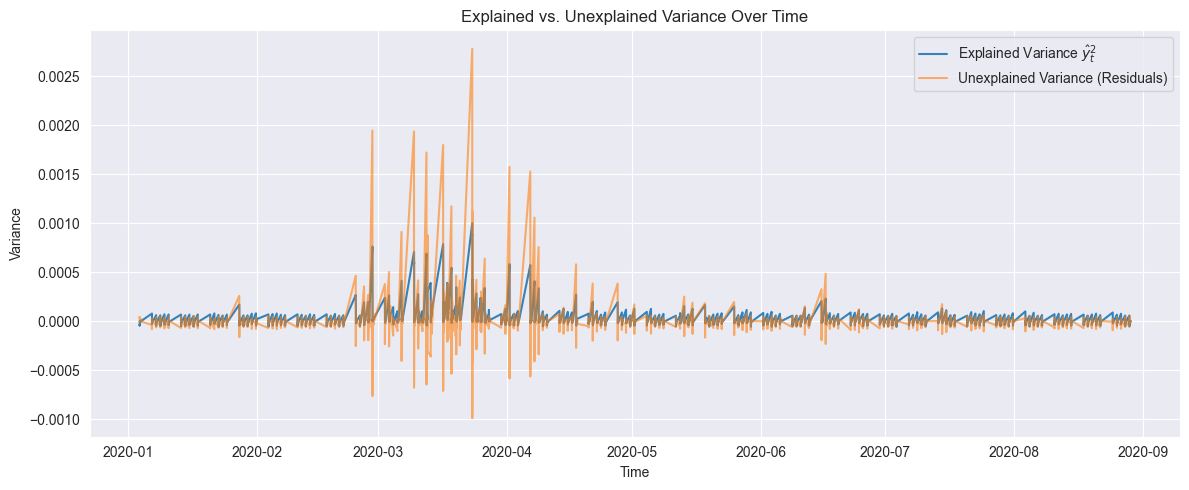

In [52]:
#import matplotlib.pyplot as plt

# 1. Vorhersagewerte und Residuen aus dem Modell
y_true = df_name_dummies["y^2"].iloc[j-1:].copy()  # Ab .iloc[j-1:], da rolling window
y_pred = model_FE.fittedvalues
residuals = model_FE.resid

# 2. Zeitindex
time_index = y_true.index

# 3. Plot
plt.figure(figsize=(12, 5))
#plt.plot(time_index, y_true, label="Observed Variance $y_t^2$", alpha=0.6)
plt.plot(time_index, y_pred, label=r"Explained Variance $\hat{y}_t^2$", alpha=0.9)
plt.plot(time_index, residuals, label=r"Unexplained Variance (Residuals)", linestyle='-', alpha=0.6)

plt.title("Explained vs. Unexplained Variance Over Time")
plt.ylabel("Variance")
plt.xlabel("Time")
plt.legend()
plt.tight_layout()
plt.show()


In [53]:

import matplotlib.pyplot as plt

# Sicherstellen, dass omega_components_df existiert und einen Zeitindex hat
# Falls kein Zeitindex vorhanden ist, einfach Index als Pseudozeit verwenden
omega_components_df.index = range(1, len(omega_components_df) + 1)

# Plot erstellen
plt.figure(figsize=(12, 6))

for col in omega_components_df.columns:
    plt.plot(omega_components_df.index, omega_components_df[col], label=col)

plt.title(r"Time Series of $\Omega_i$ (per Event Type) Across Bootstrap Samples")
plt.xlabel(r"Bootstrap Sample Index")
plt.ylabel(r"$\Omega_i$ (Share of Variance Explained)")
plt.legend(title="Event Type")
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'omega_components_df' is not defined

---
---
## 4.1 Bootstrapping Analysis for Statistical Inference on $\Omega_k$ and Coefficients

This section describes the implementation of a bootstrapping procedure used to assess the robustness and uncertainty of the $\Omega_k$ statistic and associated event-type coefficients ($\beta_i$). Bootstrapping is a non-parametric resampling technique that allows us to approximate the sampling distribution of a statistic without strong distributional assumptions.

---

### Why Bootstrapping?

In financial econometrics, it is often difficult to derive exact confidence intervals for complex statistics like $\Omega_k$, especially in small samples or when the error structure is unknown. Bootstrapping helps us to:

- Estimate the standard errors of model parameters (e.g. $\beta_i$)
- Derive confidence intervals for $\Omega_k$ and its individual components
- Evaluate the statistical stability of findings across different samples

---

### Implementation Overview

1. **Initial Model Estimation:**  
   An OLS regression is fitted to the full dataset to identify the top $k$ most influential event types based on their $t$-statistics.

2. **Bootstrap Sampling:**  
   The dataset is resampled with replacement $n=1000$ times. For each sample:
   - A regression model is re-estimated
   - $\Omega_k$ is recalculated
   - Each component $\omega_i = \frac{\hat{\beta}_i \cdot \mathbb{E}[D_i]}{\mathbb{E}[y_t^2]}$ is saved
   - The estimated coefficients $\hat{\beta}_i$ for the top $k$ events are stored

3. **Summary Statistics:**  
   For all sampled values of $\beta_i$ and $\omega_i$, the following are computed:
   - Mean  
   - Standard error (sample standard deviation)  
   - 95% Confidence Interval via empirical percentiles (2.5% and 97.5%)

---

### Output Tables

The code produces three summary tables:

- **Beta Coefficients Summary:**  
  Contains the mean, standard error, and confidence intervals for each event type’s estimated coefficient $\hat{\beta}_i$.

- **$\Omega_k$ Summary:**  
  Displays the bootstrapped distribution of the total explanatory power $\Omega_k$ across all resamples.

- **Individual $\omega_i$ Summary:**  
  Breaks down the contribution of each top-$k$ event to the total $\Omega_k$, showing which events contribute most to market volatility.

---

### Interpretation

If an event type consistently shows a high $\omega_i$ across bootstrap samples, it provides robust evidence that this event explains a meaningful share of volatility. Wide confidence intervals, on the other hand, indicate statistical uncertainty.

This approach ensures that our conclusions about market-impacting news are not driven by sample noise but reflect repeatable, data-driven patterns.


Bootstrapping: 100%|██████████| 1000/1000 [00:04<00:00, 243.48it/s]


=== Beta Coefficients Summary ===
                      mean  std_error   ci_2.5%  ci_97.5%
Beta Coefficient                                         
D_Ad Hoc          0.000066   0.000027  0.000021  0.000122
D_Macro Release   0.000031   0.000010  0.000012  0.000053
D_Auction         0.000010   0.000007 -0.000003  0.000024
D_Central Bank    0.000004   0.000008 -0.000012  0.000020

=== Omega_k Summary ===
            mean  std_error   ci_2.5%  ci_97.5%
Omega_k  0.55745   0.060727  0.438155  0.680026

=== Individual Omega_i Summary ===
                          mean  std_error   ci_2.5%  ci_97.5%
Event Type (Omega_i)                                         
D_Ad Hoc              0.129526   0.050406  0.041257  0.234812
D_Macro Release       0.255496   0.079156  0.107679  0.408178
D_Auction             0.137955   0.085451 -0.037030  0.303351
D_Central Bank        0.034474   0.071325 -0.096522  0.175595


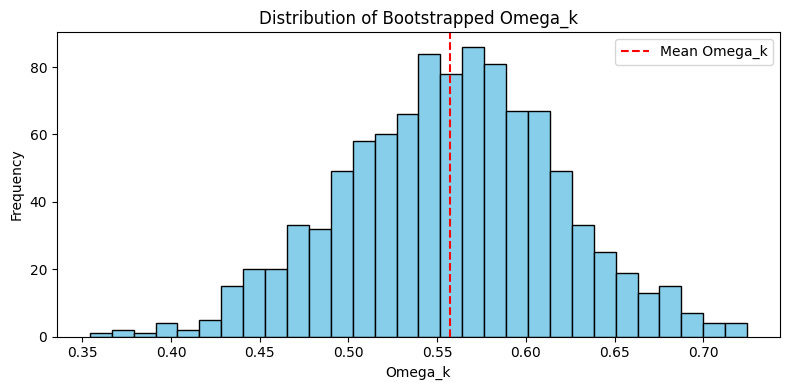

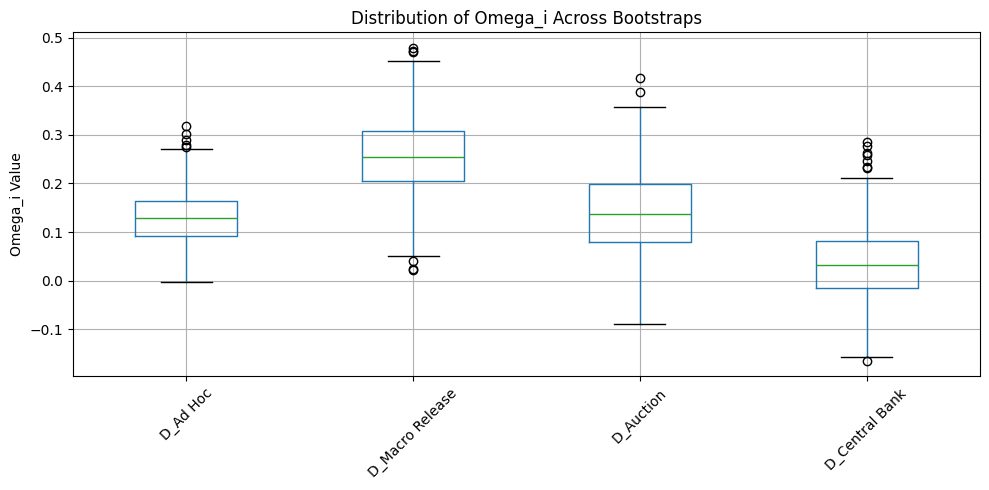

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Initialisiere top_k_columns anhand des Originals
initial_model = run_regression(df_complete, window_amt=4)
_, top_k_columns = compute_omega_k(initial_model, df_complete, k=4)

# Bootstrapping-Funktion
def bootstrap(df: pd.DataFrame, n: int = 1000):
    for _ in tqdm(range(n), desc="Bootstrapping"):
        yield df.sample(frac=1, replace=True)

# Speicher für Ergebnisse
all_omegas = []
all_omega_components = {col: [] for col in top_k_columns}
all_beta_samples = []

# Bootstrapping durchführen
for sampled_df in bootstrap(df_complete, n=1000):
    model = run_regression(sampled_df, window_amt=4)
    omega_k, top_cols = compute_omega_k(model, sampled_df, k=4)
    all_omegas.append(omega_k)
    
    # Betas speichern
    betas = model.params[top_k_columns]
    all_beta_samples.append(betas)

    # Einzelne Komponenten von Omega berechnen
    mean_y2 = sampled_df["y^2"].mean()
    for col in top_k_columns:
        beta_i = model.params[col]
        p_i = sampled_df[col].mean()
        omega_i = (beta_i * p_i) / mean_y2
        all_omega_components[col].append(omega_i)

# In DataFrames umwandeln
beta_df = pd.DataFrame(all_beta_samples)
omega_series = pd.Series(all_omegas, name="Omega_k")
omega_components_df = pd.DataFrame(all_omega_components)

# Funktion für CI und Standardfehler
def summary_stats(series):
    return {
        "mean": np.mean(series),
        "std_error": np.std(series, ddof=1),
        "ci_2.5%": np.percentile(series, 2.5),
        "ci_97.5%": np.percentile(series, 97.5)
    }

# Zusammenfassungen erstellen
beta_summary = beta_df.apply(lambda col: pd.Series(summary_stats(col))).T
beta_summary.index.name = "Beta Coefficient"

omega_summary = pd.DataFrame([summary_stats(omega_series)], index=["Omega_k"])
omega_indiv_summary = omega_components_df.apply(lambda col: pd.Series(summary_stats(col))).T
omega_indiv_summary.index.name = "Event Type (Omega_i)"

# Ausgabe
print("=== Beta Coefficients Summary ===")
print(beta_summary.round(6))
print("\n=== Omega_k Summary ===")
print(omega_summary.round(6))
print("\n=== Individual Omega_i Summary ===")
print(omega_indiv_summary.round(6))

# ------------------- Plots -------------------

# Plot 1: Verteilung von Omega_k
plt.figure(figsize=(8, 4))
plt.hist(omega_series, bins=30, color='skyblue', edgecolor='black')
plt.axvline(omega_series.mean(), color='red', linestyle='--', label='Mean Omega_k')
plt.title("Distribution of Bootstrapped Omega_k")
plt.xlabel("Omega_k")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Boxplot der Omega_i Komponenten
plt.figure(figsize=(10, 5))
omega_components_df.boxplot()
plt.title("Distribution of Omega_i Across Bootstraps")
plt.ylabel("Omega_i Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4.2 Bootstrap-Based Interpretation of Coefficients and $\omega$-Values

This summary uses bootstrapping to assess the stability and uncertainty of estimated beta coefficients ($\hat{\beta}_i$) and explained variance shares ($\omega_k$, $\omega_i$).

#### Beta Coefficients

- **Ad Hoc** shows the highest and most robust beta ($\hat{\beta} \approx 6.6 \times 10^{-5}$) with a tight 95% CI — consistent across bootstrap samples.
- **Macro Release** has a lower beta ($3.1 \times 10^{-5}$), but its confidence interval also excludes zero, confirming statistical significance.
- **Auction** and **Central Bank** betas have wide intervals and include zero in many resamples, indicating **high uncertainty and weak stability**.

#### $\omega_k$ (Total Explained Variance)

- Mean $\omega_k = 0.56$, with bootstrap CI [0.44, 0.68].
- The histogram shows a **concentrated and symmetric distribution**, confirming that the explanatory power of the model is **robust across resamples**.

#### $\omega_i$ (Event-Level Variance Shares)

- **Macro Release** has the highest and most stable contribution ($\omega_i \approx 0.26$), with narrow spread in the boxplot.
- **Ad Hoc** is moderately stable ($\omega_i \approx 0.13$), though more sensitive to sampling variation due to lower event frequency.
- **Auctions** and **Central Bank events** show **wide dispersion and CI overlap with zero**, revealing that their explanatory role is **fragile and sample-dependent**.

### Conclusion

Bootstrapping confirms the **reliability of Macro and Ad Hoc effects**, both in impact (beta) and overall contribution ($\omega_i$). In contrast, Auction and Central Bank results are **unstable** and likely **not robust to sample variation** — a key insight when assessing the structural importance of news types.
